# Module 4.3 — Recommender Systems

Netflix, Spotify, Amazon — recommendation is one of the highest-value applications of ML. The core idea connects directly to what you learned in 4.2: learn a dense embedding for every user and every item, then predict how much a user will like an item from those embeddings.

**What you'll learn:**
- The recommendation problem: explicit ratings vs implicit feedback
- Matrix factorization: the classic approach, expressed as two `nn.Embedding` layers
- Neural collaborative filtering: replace the dot product with an MLP (Multi-Layer Perceptron)
- Negative sampling: how to train on implicit feedback (clicks, watches)
- Making actual recommendations: top-K inference for a user
- Visualising what the learned item embeddings capture

**Dataset:** MovieLens 1M — 1,000,209 explicit ratings (1–5 stars) from 6,040 users on 3,706 movies (scaled up from the original 100K version).

**Colab variant of this notebook.** Adjustments vs. the local copy:
- Batch sizes bumped up (training: 512→4096, implicit: 1024→8192, ranking eval: 2048→8192) to take advantage of the parallelism a real GPU (Graphics Processing Unit) offers — fewer, bigger forward/backward calls instead of many tiny ones (the local run was dominated by per-batch dispatch overhead, not actual compute).
- A Plotly renderer fix for Colab's environment (c03).
- Everything else (`device` selection, data loading, model code) is already portable — no other changes needed.

**Before running:** Runtime → Change runtime type → Hardware accelerator → GPU (T4 is fine). Data re-downloads each fresh session since Colab's storage is ephemeral — harmless, just ~30s for the ~24MB ml-1m zip.

## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import pathlib
import sys

# Colab sometimes fails to auto-detect its environment for Plotly's
# interactive output (renders blank instead of the chart) — force it.
if 'google.colab' in sys.modules:
    import plotly.io as pio
    pio.renderers.default = 'colab'

print(f'PyTorch version: {torch.__version__}')
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

PyTorch version: 2.11.0+cu128
Using device: cuda


## 2. The Recommendation Problem

We have a matrix R where `R[u, i]` is user u's rating of item i. The matrix is **extremely sparse** — most users have only rated a tiny fraction of all movies. Our job is to fill in the missing entries.

### Explicit vs implicit feedback

| Type | Examples | What we have |
|---|---|---|
| **Explicit** | Star ratings, thumbs up/down | A real number (1–5) |
| **Implicit** | Clicks, watches, skips | Binary signal — observed or not |

Explicit feedback is cleaner to learn from (just predict the number), but rare — most users don't rate things. Implicit is abundant but noisier: a watch doesn't mean you liked it. We'll work with explicit ratings first, then discuss how implicit systems differ.

### The embedding intuition

Assign every user a vector **u** and every item a vector **v** (both length D). The predicted rating is:

```
r_hat[u, i] = u · v  +  bias_u  +  bias_i
```

If user u and item i have similar "taste vectors", their dot product is large → high predicted rating. This is called **matrix factorization** because we're approximating the full rating matrix R ≈ U × Vᵀ.

The connection to 4.2: this is exactly the same `nn.Embedding` lookup you used for words. Users and movies are tokens; we learn their representations from data.

## 3. Load MovieLens 1M

Scaling up from the 100K version used earlier: 10x more ratings (1M vs 100K), 6,040 users, 3,706 rated movies, plus per-user demographics (age, gender, occupation, zip). The `.dat` files use `::` as a separator instead of 100K's tab/pipe.

One important difference from 100K: **movie IDs in this dataset have gaps** (not every integer between 1 and ~3,952 is used), whereas 100K's IDs were cleanly contiguous. Since the rest of this notebook relies on `item_id - 1` being a safe, dense zero-based index for `nn.Embedding`, we remap raw IDs to a contiguous `1..n` range right after loading — everything downstream then works unmodified.</cell id="c05">
</invoke>


In [2]:
data_dir = pathlib.Path('./data/ml-1m')
if not data_dir.exists():
    data_dir.parent.mkdir(parents=True, exist_ok=True)  # ./data/ won't exist on a fresh filesystem (e.g. Colab)
    url = 'https://files.grouplens.org/datasets/movielens/ml-1m.zip'
    print('Downloading MovieLens 1M...')
    urllib.request.urlretrieve(url, './data/ml-1m.zip')
    with zipfile.ZipFile('./data/ml-1m.zip') as zf:
        zf.extractall('./data')
    print('Done.')
else:
    print('Data already downloaded.')

ratings = pd.read_csv('./data/ml-1m/ratings.dat', sep='::', engine='python', encoding='latin-1',
                      names=['user_id', 'item_id', 'rating', 'timestamp'])
movies  = pd.read_csv('./data/ml-1m/movies.dat', sep='::', engine='python', encoding='latin-1',
                      usecols=[0, 1], names=['item_id', 'title'])

# Remap raw IDs to a contiguous 1..N range. ml-1m's movie IDs have gaps
# (unlike ml-100k's clean 1..1682), so the old "just subtract 1" trick isn't
# safe here — this keeps every downstream cell's zero-indexing assumption true.
user_id_map = {old: new for new, old in enumerate(sorted(ratings.user_id.unique()), start=1)}
item_id_map = {old: new for new, old in enumerate(sorted(ratings.item_id.unique()), start=1)}
ratings['user_id'] = ratings['user_id'].map(user_id_map)
ratings['item_id'] = ratings['item_id'].map(item_id_map)
movies['item_id']  = movies['item_id'].map(item_id_map)
movies = movies.dropna(subset=['item_id']).copy()   # drop movies never rated (not in item_id_map)
movies['item_id'] = movies['item_id'].astype(int)


def find_item_id(title_substr):
    """Look up a movie's (remapped) item_id by a case-insensitive title
    substring — dataset-agnostic replacement for hardcoding raw MovieLens IDs,
    which differ between ml-100k and ml-1m for the same movie."""
    match = movies[movies.title.str.contains(title_substr, case=False, regex=False)]
    return int(match.iloc[0].item_id)


n_users = ratings.user_id.nunique()
n_items = ratings.item_id.nunique()

print(f'Ratings: {len(ratings):,}')
print(f'Users:   {n_users:,}')
print(f'Movies:  {n_items:,}')
print(f'Rating range: {ratings.rating.min()} – {ratings.rating.max()}')
sparsity = 1 - len(ratings) / (n_users * n_items)
print(f'Matrix sparsity: {sparsity:.1%}  (most entries are missing)')
ratings.head()

Done.
Ratings: 1,000,209
Users:   6,040
Movies:  3,706
Rating range: 1 – 5
Matrix sparsity: 95.5%  (most entries are missing)


,user_id,item_id,rating,timestamp
0,1,1105,5,978300760
1,1,640,3,978302109
2,1,854,3,978301968
3,1,3178,4,978300275
4,1,2163,5,978824291


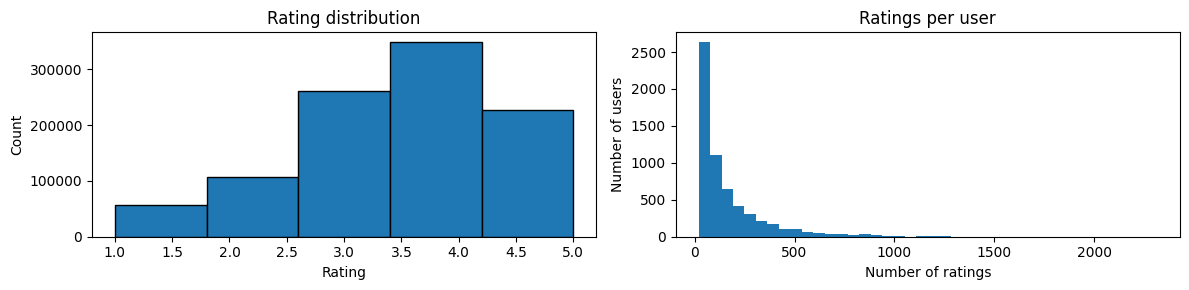

Median ratings per user: 96
Most active user: 2314 ratings


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].hist(ratings.rating, bins=5, edgecolor='black')
axes[0].set_title('Rating distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

ratings_per_user = ratings.groupby('user_id').size()
axes[1].hist(ratings_per_user, bins=40)
axes[1].set_title('Ratings per user')
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('Number of users')

plt.tight_layout()
plt.show()
print(f'Median ratings per user: {ratings_per_user.median():.0f}')
print(f'Most active user: {ratings_per_user.max()} ratings')

## 4. Dataset and DataLoader

In [4]:
class RatingsDataset(Dataset):
    def __init__(self, df):
        # IDs in the file start at 1 — zero-index them for nn.Embedding
        self.users   = torch.tensor(df.user_id.values - 1, dtype=torch.long)
        self.items   = torch.tensor(df.item_id.values - 1, dtype=torch.long)
        self.ratings = torch.tensor(df.rating.values,      dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]


dataset = RatingsDataset(ratings)
n_train = int(0.8 * len(dataset))
n_test  = len(dataset) - n_train
train_data, test_data = random_split(dataset, [n_train, n_test],
                                     generator=torch.Generator().manual_seed(42))

# Bumped from 512 (local/MPS) to 4096 — a real GPU has plenty of headroom for
# bigger batches, and fewer/bigger forward-backward calls means less of the
# per-batch dispatch overhead that dominated the local run's wall time.
train_loader = DataLoader(train_data, batch_size=4096, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=4096, shuffle=False)

print(f'Train: {len(train_data):,}  |  Test: {len(test_data):,}')

Train: 800,167  |  Test: 200,042


## 5. Matrix Factorization (MF)

Two embedding tables — one for users, one for items — plus a scalar bias for each. The prediction is their dot product plus the biases:

```
r_hat = (user_emb[u] · item_emb[i]) + user_bias[u] + item_bias[i]
```

We train with MSE (Mean Squared Error) loss on observed ratings. During inference we clamp predictions to [1, 5] to stay in rating range.

The bias terms matter: some users rate everything 5 stars; some movies are universally loved. The biases capture those offsets so the embeddings can focus on interaction effects.

In [5]:
class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, n_factors=32):
        super().__init__()
        self.user_emb  = nn.Embedding(n_users, n_factors)
        self.item_emb  = nn.Embedding(n_items, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        nn.init.normal_(self.user_emb.weight,  std=0.01)
        nn.init.normal_(self.item_emb.weight,  std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, users, items):
        u    = self.user_emb(users)              # [B, n_factors]
        v    = self.item_emb(items)              # [B, n_factors]
        dot  = (u * v).sum(dim=1)               # [B]
        bias = (self.user_bias(users).squeeze()
                + self.item_bias(items).squeeze())
        return dot + bias                        # raw score


mf_model = MatrixFactorization(n_users, n_items, n_factors=32).to(device)
print(f'MF parameters: {sum(p.numel() for p in mf_model.parameters()):,}')

MF parameters: 321,618


## 6. Neural Collaborative Filtering (NCF)

MF forces the user-item interaction to be a dot product — a linear combination. NCF replaces that with an MLP, which can learn non-linear interactions:

```
x     = concat(user_emb[u], item_emb[i])   # [2 * n_factors]
r_hat = MLP(x)                              # learned non-linear score
```

The trade-off: more expressive, but also more parameters and slower to train. In practice, the best systems combine both (dot product + MLP in parallel, then merge).

In [6]:
class NeuralCF(nn.Module):
    def __init__(self, n_users, n_items, n_factors=32, hidden=128):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, n_factors)
        self.item_emb = nn.Embedding(n_items, n_factors)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        self.mlp = nn.Sequential(
            nn.Linear(n_factors * 2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden // 2),   nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, users, items):
        u = self.user_emb(users)              # [B, n_factors]
        v = self.item_emb(items)              # [B, n_factors]
        x = torch.cat([u, v], dim=1)          # [B, n_factors * 2]
        return self.mlp(x).squeeze()          # [B]


ncf_model = NeuralCF(n_users, n_items, n_factors=32, hidden=128).to(device)
print(f'NCF parameters: {sum(p.numel() for p in ncf_model.parameters()):,}')

NCF parameters: 328,513


## 7. Training

We use MSE loss and report **RMSE (Root Mean Squared Error)** — same units as the ratings (stars). A naive baseline that always predicts the mean rating (~3.5) gets about RMSE 1.1. A good model should get below 0.95.

In [7]:
def train_epoch_rec(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for users, items, ratings_batch in loader:
        users, items, ratings_batch = users.to(device), items.to(device), ratings_batch.to(device)
        optimizer.zero_grad()
        preds = model(users, items)
        loss = criterion(preds, ratings_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(ratings_batch)
    return (total_loss / len(loader.dataset)) ** 0.5  # RMSE


@torch.no_grad()
def evaluate_rec(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for users, items, ratings_batch in loader:
        users, items, ratings_batch = users.to(device), items.to(device), ratings_batch.to(device)
        preds = model(users, items)
        total_loss += criterion(preds, ratings_batch).item() * len(ratings_batch)
    return (total_loss / len(loader.dataset)) ** 0.5  # RMSE

In [8]:
import copy

criterion = nn.MSELoss()

# Tuned from the earlier run, where MF's train RMSE kept falling while its
# test RMSE rose above the naive baseline (classic overfitting). Three fixes:
# 1) MF's lr dropped from 1e-2 to match NCF's 1e-3 (1e-2 let it memorize fast)
# 2) weight_decay (L2 penalty) added to both, penalizing large embedding values
# 3) early stopping: each model stops once its test RMSE hasn't improved for
#    PATIENCE epochs, and we restore its best (not final) checkpoint after
mf_optimizer  = optim.Adam(mf_model.parameters(),  lr=1e-3, weight_decay=1e-5)
ncf_optimizer = optim.Adam(ncf_model.parameters(), lr=1e-3, weight_decay=1e-5)

EPOCHS = 20
PATIENCE = 3  # stop a model once test RMSE hasn't improved for this many epochs

mf_history  = {'train': [], 'test': []}
ncf_history = {'train': [], 'test': []}

mf_best_rmse = ncf_best_rmse = float('inf')
mf_best_state = ncf_best_state = None
mf_patience = ncf_patience = 0
mf_stopped = ncf_stopped = False

print('Training MF and NCF in parallel (with early stopping)...')
for epoch in range(1, EPOCHS + 1):
    if not mf_stopped:
        mf_train = train_epoch_rec(mf_model, train_loader, mf_optimizer, criterion)
        mf_test  = evaluate_rec(mf_model, test_loader, criterion)
        mf_history['train'].append(mf_train)
        mf_history['test'].append(mf_test)
        if mf_test < mf_best_rmse:
            mf_best_rmse, mf_best_state, mf_patience = mf_test, copy.deepcopy(mf_model.state_dict()), 0
        else:
            mf_patience += 1
            if mf_patience >= PATIENCE:
                mf_stopped = True
                print(f'  MF early-stopped after epoch {epoch} (best test RMSE {mf_best_rmse:.4f})')

    if not ncf_stopped:
        ncf_train = train_epoch_rec(ncf_model, train_loader, ncf_optimizer, criterion)
        ncf_test  = evaluate_rec(ncf_model, test_loader, criterion)
        ncf_history['train'].append(ncf_train)
        ncf_history['test'].append(ncf_test)
        if ncf_test < ncf_best_rmse:
            ncf_best_rmse, ncf_best_state, ncf_patience = ncf_test, copy.deepcopy(ncf_model.state_dict()), 0
        else:
            ncf_patience += 1
            if ncf_patience >= PATIENCE:
                ncf_stopped = True
                print(f'  NCF early-stopped after epoch {epoch} (best test RMSE {ncf_best_rmse:.4f})')

    if epoch % 5 == 0:
        print(f'Epoch {epoch:02d} | MF  train: {mf_history["train"][-1]:.4f}, test: {mf_history["test"][-1]:.4f}'
              f'{" (stopped)" if mf_stopped else ""} | '
              f'NCF train: {ncf_history["train"][-1]:.4f}, test: {ncf_history["test"][-1]:.4f}'
              f'{" (stopped)" if ncf_stopped else ""}')

    if mf_stopped and ncf_stopped:
        print(f'Both models early-stopped by epoch {epoch}.')
        break

# Restore each model's best-performing checkpoint (may not be the final epoch trained)
mf_model.load_state_dict(mf_best_state)
ncf_model.load_state_dict(ncf_best_state)

print(f'\nRestored best checkpoints — MF best test RMSE: {mf_best_rmse:.4f} | NCF best test RMSE: {ncf_best_rmse:.4f}')

Training MF and NCF in parallel (with early stopping)...
Epoch 05 | MF  train: 0.9309, test: 0.9284 | NCF train: 0.8847, test: 0.8883
Epoch 10 | MF  train: 0.9108, test: 0.9150 | NCF train: 0.8610, test: 0.8757
Epoch 15 | MF  train: 0.9073, test: 0.9117 | NCF train: 0.8486, test: 0.8762
Epoch 20 | MF  train: 0.8987, test: 0.9039 | NCF train: 0.8285, test: 0.8716

Restored best checkpoints — MF best test RMSE: 0.9039 | NCF best test RMSE: 0.8716


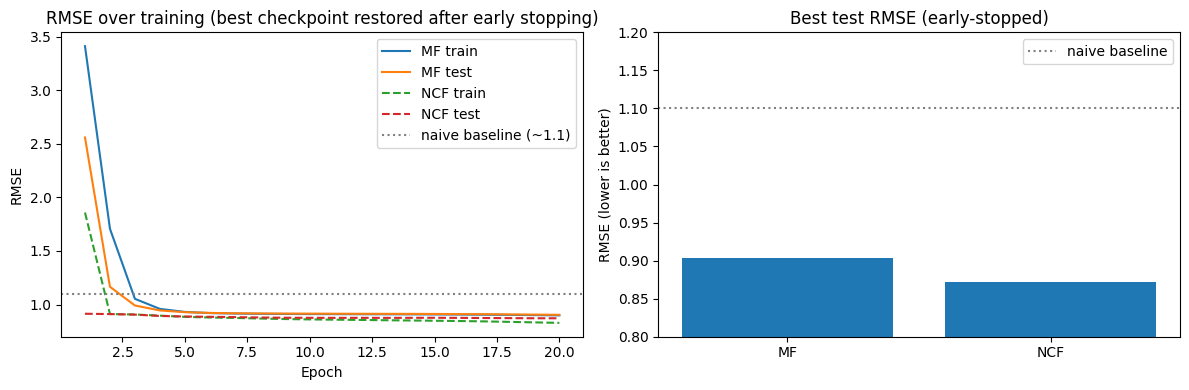

Best MF  test RMSE: 0.9039  (stopped after 20 epochs)
Best NCF test RMSE: 0.8716  (stopped after 20 epochs)
Naive baseline (always predict mean rating): ~1.1 RMSE


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Each model may have stopped at a different epoch, so plot against its own
# history length rather than assuming both ran the full EPOCHS.
mf_epochs  = range(1, len(mf_history['train']) + 1)
ncf_epochs = range(1, len(ncf_history['train']) + 1)
ax1.plot(mf_epochs, mf_history['train'],  label='MF train')
ax1.plot(mf_epochs, mf_history['test'],   label='MF test')
ax1.plot(ncf_epochs, ncf_history['train'], label='NCF train', linestyle='--')
ax1.plot(ncf_epochs, ncf_history['test'],  label='NCF test',  linestyle='--')
ax1.axhline(y=1.1, color='gray', linestyle=':', label='naive baseline (~1.1)')
ax1.set_title('RMSE over training (best checkpoint restored after early stopping)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('RMSE')
ax1.legend()

models = ['MF', 'NCF']
best_test = [mf_best_rmse, ncf_best_rmse]
ax2.bar(models, best_test)
ax2.axhline(y=1.1, color='gray', linestyle=':', label='naive baseline')
ax2.set_title('Best test RMSE (early-stopped)')
ax2.set_ylabel('RMSE (lower is better)')
ax2.set_ylim(0.8, 1.2)
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Best MF  test RMSE: {mf_best_rmse:.4f}  (stopped after {len(mf_history["train"])} epochs)')
print(f'Best NCF test RMSE: {ncf_best_rmse:.4f}  (stopped after {len(ncf_history["train"])} epochs)')
print('Naive baseline (always predict mean rating): ~1.1 RMSE')

## 8. Top-K Recommendations

At inference time, we want to answer: "given this user, which movies should we recommend?" We score every movie the user hasn't seen, then return the top K.

In [10]:
@torch.no_grad()
def recommend(model, user_id_1indexed, top_k=10):
    model.eval()
    uid = user_id_1indexed - 1  # zero-index

    # Score all items for this user
    user_tensor = torch.tensor([uid] * n_items, dtype=torch.long).to(device)
    item_tensor = torch.arange(n_items, dtype=torch.long).to(device)
    scores = model(user_tensor, item_tensor).cpu().numpy()

    # Mask out already-rated movies
    seen_items = set(ratings[ratings.user_id == user_id_1indexed].item_id.values - 1)
    scores[list(seen_items)] = -np.inf

    top_indices = np.argsort(scores)[::-1][:top_k]
    print(f'Top {top_k} recommendations for user {user_id_1indexed} '
          f'(rated {len(seen_items)} movies already):')
    for rank, idx in enumerate(top_indices, 1):
        title = movies[movies.item_id == idx + 1]['title'].values[0]
        print(f'  {rank:2d}. {title}  (predicted score: {scores[idx]:.2f})')


# We hold off calling recommend() here — all four models (MF, NCF, ImplicitMF,
# Two-Tower) get compared side-by-side in one place, right after they're all
# trained, so their top-10 lists can actually be read next to each other
# instead of scattered across sections.


--- Matrix Factorization ---
Top 10 recommendations for user 1 (rated 53 movies already):
   1. Wrong Trousers, The (1993)  (predicted score: 4.79)
   2. Usual Suspects, The (1995)  (predicted score: 4.78)
   3. Sanjuro (1962)  (predicted score: 4.76)
   4. Godfather, The (1972)  (predicted score: 4.76)
   5. Shawshank Redemption, The (1994)  (predicted score: 4.76)
   6. Third Man, The (1949)  (predicted score: 4.75)
   7. Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)  (predicted score: 4.74)
   8. Double Indemnity (1944)  (predicted score: 4.69)
   9. North by Northwest (1959)  (predicted score: 4.68)
  10. Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)  (predicted score: 4.68)

--- Neural CF ---
Top 10 recommendations for user 1 (rated 53 movies already):
   1. Color Purple, The (1985)  (predicted score: 4.73)
   2. King of Masks, The (Bian Lian) (1996)  (predicted score: 4.70)
   3. Smashing Time (1967)  (predicted score: 4.70)
   4. Quiet Man, The (1952)  (pre

## 10. Implicit Feedback and Negative Sampling

Most real recommender data is **implicit** — you know what a user clicked or watched, but not what they would have rated. There are no negatives in the data: absence of a watch doesn't mean dislike, it could just mean the user never saw it.

### The training setup

We treat observed interactions as **positive** (label = 1) and sample random unseen items as **negatives** (label = 0). The model is trained to output high scores for positives and low scores for negatives, using binary cross-entropy (BCE) loss:

```python
loss = BCEWithLogitsLoss(model(u, i_pos), 1)
     + BCEWithLogitsLoss(model(u, i_neg), 0)
```

### Why negative sampling matters

Without negatives, the model can trivially achieve zero loss by predicting high scores everywhere. Negative sampling creates the learning signal: "predict this item higher than those random unseen items."

The number of negatives per positive (negative ratio) is a hyperparameter — typically 1:1 to 1:5. More negatives = harder training signal but slower epochs.

### Evaluation with implicit feedback

RMSE doesn't apply anymore. Instead:
- **Hit Rate @ K**: for each test user, does any of their held-out items appear in the top-K predicted?
- **NDCG (Normalized Discounted Cumulative Gain) @ K**: like hit rate but rewards higher-ranked hits more

We won't implement this fully here (it needs a different data split), but it's the standard setup for production recommenders.

In [14]:
# Implicit feedback training loop. Positives = liked (>=4 stars). Negatives
# come from two sources: explicit dislikes (<=2 stars, used directly — we
# already know these are negatives, no need to guess) plus randomly sampled
# unrated items (rejection-sampled to avoid landing on anything the user
# rated 3+ stars, so a random "negative" never contradicts a real opinion).
# 3-star ratings ("it was fine") are excluded from training entirely as
# genuinely ambiguous — same >=4 threshold used for the Hit Rate@K ground
# truth later on, for consistency.

class ImplicitMF(nn.Module):
    def __init__(self, n_users, n_items, n_factors=32):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, n_factors)
        self.item_emb = nn.Embedding(n_items, n_factors)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

    def forward(self, users, items):
        u = self.user_emb(users)
        v = self.item_emb(items)
        return (u * v).sum(dim=1)  # raw logit (no sigmoid — BCEWithLogitsLoss handles it)


implicit_model = ImplicitMF(n_users, n_items).to(device)
implicit_optim = optim.Adam(implicit_model.parameters(), lr=1e-2)
bce_loss = nn.BCEWithLogitsLoss()

pos_mask = ratings.rating >= 4
neg_mask = ratings.rating <= 2

pos_users = torch.tensor(ratings.loc[pos_mask, 'user_id'].values - 1, dtype=torch.long)
pos_items = torch.tensor(ratings.loc[pos_mask, 'item_id'].values - 1, dtype=torch.long)
explicit_neg_users = torch.tensor(ratings.loc[neg_mask, 'user_id'].values - 1, dtype=torch.long)
explicit_neg_items = torch.tensor(ratings.loc[neg_mask, 'item_id'].values - 1, dtype=torch.long)

print(f'Positives (>=4 stars): {len(pos_users):,} | Explicit negatives (<=2 stars): '
      f'{len(explicit_neg_users):,} | Excluded as ambiguous (3 stars): {(ratings.rating == 3).sum():,}')

# Items to protect from random negative sampling: anything rated 3+ (liked or
# neutral) — a randomly-sampled "negative" landing on one of these would be a
# false negative. Items rated <=2 are fine to occasionally re-sample too
# (harmless duplicate of a real negative already in the training set).
user_protected_items = [set() for _ in range(n_users)]
for u, i in zip(ratings.loc[ratings.rating >= 3, 'user_id'].values - 1,
                ratings.loc[ratings.rating >= 3, 'item_id'].values - 1):
    user_protected_items[u].add(i)


def sample_negatives(users, n_items, user_protected_items):
    """Sample one random item per user, resampling on collision with a
    liked/neutral (3+ star) item (rejection sampling), so random negatives
    genuinely don't include anything the user liked or felt neutral about."""
    users_np = users.numpy()
    neg_items = np.random.randint(0, n_items, size=len(users_np))
    collisions = 0
    for idx in range(len(users_np)):
        u = users_np[idx]
        while neg_items[idx] in user_protected_items[u]:
            neg_items[idx] = np.random.randint(0, n_items)
            collisions += 1
    return torch.from_numpy(neg_items).long(), collisions


implicit_history = []

for epoch in range(1, 11):
    implicit_model.train()
    # One random negative per positive, sampled from items the user never rated 3+ stars on
    random_neg_items, n_collisions = sample_negatives(pos_users, n_items, user_protected_items)

    # Combine: real positives, real (explicit, <=2 star) negatives, and random negatives
    all_users  = torch.cat([pos_users, explicit_neg_users, pos_users])
    all_items  = torch.cat([pos_items, explicit_neg_items, random_neg_items])
    all_labels = torch.cat([torch.ones(len(pos_users)),
                            torch.zeros(len(explicit_neg_users)),
                            torch.zeros(len(pos_users))])

    # Mini-batch SGD
    idx = torch.randperm(len(all_users))
    total_loss = 0.0
    batch_size = 8192  # bumped from 1024 — same reasoning as train_loader above
    for start in range(0, len(idx), batch_size):
        b = idx[start:start + batch_size]
        u, i, y = all_users[b].to(device), all_items[b].to(device), all_labels[b].to(device)
        implicit_optim.zero_grad()
        loss = bce_loss(implicit_model(u, i), y)
        loss.backward()
        implicit_optim.step()
        total_loss += loss.item()
    implicit_history.append(total_loss)
    if epoch % 2 == 0:
        print(f'Epoch {epoch:02d} | loss: {total_loss:.4f} | resampled {n_collisions} colliding negatives')

print('\nImplicit model trained — recommends based on interaction patterns, not ratings')

Positives (>=4 stars): 575,281 | Explicit negatives (<=2 stars): 163,731 | Excluded as ambiguous (3 stars): 261,197
Epoch 02 | loss: 62.8384 | resampled 56427 colliding negatives
Epoch 04 | loss: 52.3856 | resampled 55739 colliding negatives
Epoch 06 | loss: 46.8757 | resampled 55775 colliding negatives
Epoch 08 | loss: 43.7540 | resampled 56241 colliding negatives
Epoch 10 | loss: 42.1788 | resampled 56091 colliding negatives

Implicit model trained — recommends based on interaction patterns, not ratings


In [15]:
# See what the implicit model's item embeddings capture, using the same
# similar_movies() helper defined in section 9 — ImplicitMF has the same
# interface (.item_emb), so it works unchanged. (Its own top-10 recommend()
# output is compared side-by-side with the other three models further down.)

similar_movies(implicit_model, item_id_1indexed=find_item_id('Star Wars: Episode IV'))


--- Implicit MF ---
Top 10 recommendations for user 1 (rated 53 movies already):
   1. Star Wars: Episode V - The Empire Strikes Back (1980)  (predicted score: 5.72)
   2. Shawshank Redemption, The (1994)  (predicted score: 5.71)
   3. Life Is Beautiful (La Vita è bella) (1997)  (predicted score: 4.83)
   4. Little Mermaid, The (1989)  (predicted score: 4.68)
   5. Stand by Me (1986)  (predicted score: 4.59)
   6. Babe (1995)  (predicted score: 4.47)
   7. Lion King, The (1994)  (predicted score: 4.38)
   8. Breakfast Club, The (1985)  (predicted score: 4.32)
   9. Sense and Sensibility (1995)  (predicted score: 4.28)
  10. Silence of the Lambs, The (1991)  (predicted score: 4.13)

Movies most similar to "Star Wars: Episode IV - A New Hope (1977)" in embedding space:
  0.910  Star Wars: Episode V - The Empire Strikes Back (1980)
  0.886  Star Wars: Episode VI - Return of the Jedi (1983)
  0.830  Indiana Jones and the Last Crusade (1989)
  0.808  Raiders of the Lost Ark (1981)
  0.621  

## Summary

| Concept | Key takeaway |
|---|---|
| Rating matrix | Extremely sparse — the job is filling in the blanks |
| Matrix factorization | User + item `nn.Embedding` + dot product; same math as word vectors |
| Bias terms | Capture per-user and per-item offsets so embeddings learn interaction effects |
| Neural CF | Replace dot product with MLP; more expressive but more parameters |
| Implicit feedback | Treat watched/clicked as positives, sample random negatives; BCE loss not MSE |
| Top-K inference | Score all unseen items, mask rated ones, return top K |
| Embedding geometry | Similar items cluster in embedding space — same intuition as Word2Vec |

**What real systems add on top:**
- **Side features** — user demographics, item genres, context (time of day) fed into the MLP
- **Sequence models** — transformer or RNN over a user's watch history for "what to watch next"
- **Two-stage retrieval** — fast approximate nearest-neighbour search to get candidates, then a heavier re-ranking model
- **Exploration vs exploitation** — occasionally recommend outside a user's comfort zone to learn new preferences

Module 5 (Transformers) builds the sequence modelling piece that many modern recommenders use for the "next item" prediction problem.

## Bonus: Real-World Architecture — The Two-Tower Model

Netflix, YouTube, Instagram, Pinterest — the production architecture behind most large-scale recommenders is the **two-tower model** (popularized by YouTube's 2016 "Deep Neural Networks for YouTube Recommendations" paper). The surprising part: **MF above is already a minimal two-tower model.**

```
MF:          user_emb[u]  ·  item_emb[i]                         ← both towers are just an embedding lookup
Two-Tower:   user_tower(user features)  ·  item_tower(item features)   ← both towers are full MLPs
```

The user tower and item tower are each a small neural network that takes an ID embedding *plus side features* (user: demographics, watch-history stats; item: genres, language, popularity) and outputs a single dense vector. The two vectors are combined with a dot product — exactly like MF, just with much richer inputs feeding each side.

### The critical property: the towers never talk to each other until the very end

Compare this to NCF (section 6): NCF concatenates the user and item vectors together *before* the MLP, so you cannot compute anything until you know both the specific user **and** the specific item. The two-tower model keeps the user computation and the item computation **completely independent** until the final dot product. This independence is what makes it deployable at real scale:

1. **Item tower runs offline**, once, over the entire catalog (millions/billions of items) — producing a fixed table of item vectors, indexed into an **Approximate Nearest Neighbour (ANN)** structure (FAISS, ScaNN, HNSW are the real tools; we'll fake this with a brute-force cosine scan below, which is exactly what our existing `similar_movies()` already does — fine at 3,706 movies, hopeless at YouTube's scale).
2. **At request time**, only the (usually smaller) user tower runs — once, for the current user — producing a single query vector.
3. That query vector does a fast **ANN lookup** against the prebuilt item index, retrieving a few hundred candidates out of millions, without ever scoring every item individually — this is the "**Two-stage retrieval**" bullet from the Summary above, now made concrete: the two-tower model *is* the fast retrieval stage.
4. Those few hundred candidates then get passed to a **second, heavier ranking model** — often something NCF-like, which *can* afford full user-item cross-attention, because it's now only scoring hundreds of candidates instead of millions.

NCF's entangled architecture is exactly why it's typically used as that stage-2 *ranker*, not stage-1 *retriever* — it has no way to precompute anything before seeing a specific (user, item) pair.

Let's build a tiny two-tower model using the genre data sitting unused in `movies.dat` (same "hiding in plain sight" discovery as the timestamp column earlier) as the item tower's side feature.

In [16]:
# movies.dat has a 3rd column (genres, pipe-separated) that c06 dropped via
# usecols=[0, 1] — re-read it fresh and build a multi-hot genre matrix,
# using the same item_id_map from c06 so IDs line up with everything else.
movies_genres = pd.read_csv('./data/ml-1m/movies.dat', sep='::', engine='python', encoding='latin-1',
                            names=['item_id', 'title', 'genres'])
movies_genres['item_id'] = movies_genres['item_id'].map(item_id_map)
movies_genres = movies_genres.dropna(subset=['item_id']).copy()
movies_genres['item_id'] = movies_genres['item_id'].astype(int)

all_genres = sorted({g for genre_list in movies_genres.genres.str.split('|') for g in genre_list})
genre_to_idx = {g: i for i, g in enumerate(all_genres)}
print(f'{len(all_genres)} unique genres: {all_genres}')

item_genre_features = torch.zeros(n_items, len(all_genres))
for _, row in movies_genres.iterrows():
    for g in row.genres.split('|'):
        item_genre_features[row.item_id - 1, genre_to_idx[g]] = 1.0  # zero-indexed row

item_genre_features = item_genre_features.to(device)
print(f'item_genre_features shape: {tuple(item_genre_features.shape)}  (n_items x n_genres)')
print(f'Example — "{movies[movies.item_id == 1].title.values[0]}" genres: '
      f'{[g for g, i in genre_to_idx.items() if item_genre_features[0, i] == 1]}')

18 unique genres: ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
item_genre_features shape: (3706, 18)  (n_items x n_genres)
Example — "Toy Story (1995)" genres: ['Animation', "Children's", 'Comedy']


In [17]:
class TwoTowerModel(nn.Module):
    def __init__(self, n_users, n_items, item_genre_features, n_factors=32, hidden=64):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, n_factors)
        self.item_emb = nn.Embedding(n_items, n_factors)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

        n_genres = item_genre_features.shape[1]
        self.register_buffer('item_genres', item_genre_features)  # [n_items, n_genres], not trained

        # User tower: ID embedding -> MLP -> final user vector. (Real systems
        # would concatenate demographics/watch-history stats here too — this
        # dataset only gives us the ID for the ratings-based training signal.)
        self.user_tower = nn.Sequential(
            nn.Linear(n_factors, hidden), nn.ReLU(),
            nn.Linear(hidden, n_factors),
        )
        # Item tower: ID embedding + genre multi-hot -> MLP -> final item vector
        self.item_tower = nn.Sequential(
            nn.Linear(n_factors + n_genres, hidden), nn.ReLU(),
            nn.Linear(hidden, n_factors),
        )

    def user_vector(self, users):
        return self.user_tower(self.user_emb(users))

    def item_vector(self, items):
        genres = self.item_genres[items]                     # [B, n_genres]
        x = torch.cat([self.item_emb(items), genres], dim=1)  # [B, n_factors + n_genres]
        return self.item_tower(x)

    def forward(self, users, items):
        u = self.user_vector(users)
        v = self.item_vector(items)
        return (u * v).sum(dim=1)  # same combiner as MF — richer towers feeding it


two_tower_model = TwoTowerModel(n_users, n_items, item_genre_features, n_factors=32, hidden=64).to(device)
print(f'Two-Tower parameters: {sum(p.numel() for p in two_tower_model.parameters()):,}')

tt_optimizer = optim.Adam(two_tower_model.parameters(), lr=1e-3, weight_decay=1e-5)
tt_best_rmse = float('inf')
tt_best_state = None
tt_patience = 0

print('\nTraining Two-Tower model (with early stopping)...')
for epoch in range(1, EPOCHS + 1):
    tt_train = train_epoch_rec(two_tower_model, train_loader, tt_optimizer, criterion)
    tt_test  = evaluate_rec(two_tower_model, test_loader, criterion)
    if tt_test < tt_best_rmse:
        tt_best_rmse, tt_best_state, tt_patience = tt_test, copy.deepcopy(two_tower_model.state_dict()), 0
    else:
        tt_patience += 1
        if tt_patience >= PATIENCE:
            print(f'Two-Tower early-stopped after epoch {epoch} (best test RMSE {tt_best_rmse:.4f})')
            break
    if epoch % 5 == 0:
        print(f'Epoch {epoch:02d} | train: {tt_train:.4f}, test: {tt_test:.4f}')

two_tower_model.load_state_dict(tt_best_state)
print(f'\nTwo-Tower best test RMSE: {tt_best_rmse:.4f}')

Two-Tower parameters: 321,408

Training Two-Tower model (with early stopping)...
Epoch 05 | train: 0.9091, test: 0.9099
Epoch 10 | train: 0.8740, test: 0.8823
Epoch 15 | train: 0.8566, test: 0.8731
Epoch 20 | train: 0.8351, test: 0.8622

Two-Tower best test RMSE: 0.8622


In [18]:
# similar_movies() (section 9) reads mf_model.item_emb.weight directly — the
# *raw ID embedding*. For a two-tower model, the vector actually used at
# serving time is the tower's OUTPUT (ID embedding + genres, fused through
# the MLP), not the raw ID embedding alone — so it needs its own version that
# calls item_vector(). (Two-Tower's own top-10 recommend() output is compared
# side-by-side with the other three models further down.)
@torch.no_grad()
def similar_movies_two_tower(model, item_id_1indexed, top_k=8):
    all_items = torch.arange(n_items, dtype=torch.long).to(device)
    vecs = model.item_vector(all_items).cpu()      # [n_items, n_factors] — the TOWER OUTPUT
    query = vecs[item_id_1indexed - 1]
    vecs_norm  = vecs  / vecs.norm(dim=1, keepdim=True).clamp(min=1e-8)
    query_norm = query / query.norm().clamp(min=1e-8)
    sims = (vecs_norm @ query_norm).numpy()
    sims[item_id_1indexed - 1] = -1
    top_idx = np.argsort(sims)[::-1][:top_k]
    query_title = movies[movies.item_id == item_id_1indexed]['title'].values[0]
    print(f'Movies most similar to "{query_title}" in the two-tower item space:')
    for idx in top_idx:
        title = movies[movies.item_id == idx + 1]['title'].values[0]
        print(f'  {sims[idx]:.3f}  {title}')


similar_movies_two_tower(two_tower_model, item_id_1indexed=find_item_id('Star Wars: Episode IV'))


--- Two-Tower Model ---
Top 10 recommendations for user 1 (rated 53 movies already):
   1. Small Wonders (1996)  (predicted score: 4.61)
   2. King of Masks, The (Bian Lian) (1996)  (predicted score: 4.60)
   3. Remember the Titans (2000)  (predicted score: 4.58)
   4. Smashing Time (1967)  (predicted score: 4.57)
   5. Firelight (1997)  (predicted score: 4.57)
   6. Twice Upon a Yesterday (1998)  (predicted score: 4.57)
   7. Marcello Mastroianni: I Remember Yes, I Remember (1997)  (predicted score: 4.55)
   8. Butterfly (La Lengua de las Mariposas) (2000)  (predicted score: 4.54)
   9. Jupiter's Wife (1994)  (predicted score: 4.52)
  10. Window to Paris (1994)  (predicted score: 4.49)

Movies most similar to "Star Wars: Episode IV - A New Hope (1977)" in the two-tower item space:
  0.990  Superman (1978)
  0.989  Star Wars: Episode VI - Return of the Jedi (1983)
  0.988  Captain Horatio Hornblower (1951)
  0.987  Jurassic Park (1993)
  0.987  Star Trek: First Contact (1996)
  0.986  

## Compare All Models: Top-10 Recommendations Side-by-Side

Now that all four models are trained, here's the comparison in one place — MF (Matrix Factorization), NCF (Neural Collaborative Filtering), ImplicitMF, and the Two-Tower model's top-10 for the same user, right next to what that user actually rated highly. This is exactly the qualitative check that motivated the Hit Rate@K evaluation below: reading these side-by-side directly shows which model's recommendations actually resemble the user's real taste.

In [1]:
# Ground truth first, so it's the reference point for everything below
user_ratings = ratings[ratings.user_id == 1].merge(movies, on='item_id')
top_rated = user_ratings.sort_values('rating', ascending=False).head(10)
print('User 1 top-rated movies:')
for _, row in top_rated.iterrows():
    print(f'  {int(row.rating)} stars — {row.title}')

print('\n--- Matrix Factorization (MF) ---')
recommend(mf_model, user_id_1indexed=1)

print('\n--- Neural Collaborative Filtering (NCF) ---')
recommend(ncf_model, user_id_1indexed=1)

print('\n--- Implicit MF ---')
recommend(implicit_model, user_id_1indexed=1)

print('\n--- Two-Tower Model ---')
recommend(two_tower_model, user_id_1indexed=1)


NameError: name 'ratings' is not defined

## Bonus: Ranking Evaluation — Hit Rate@K and NDCG@K

Section 10 flagged this but left it unimplemented. RMSE measures how close a *predicted number* is to the true rating, on average, across the whole test set — it says nothing about whether a specific user's actual favorites end up near the top of their recommendations. That gap is exactly what we just found: MF and NCF both beat the RMSE baseline comfortably, yet **zero** of user 1's ten 5-star movies showed up in either model's top-10.

### The leave-one-out protocol (from He et al.'s 2017 NCF paper)

For each user, hold out their highest-rated (4+ star) movie from the **existing test split** (`test_data.indices` — the same split used for RMSE, so no new data leakage). Mix that one correct answer in with 99 randomly sampled movies the user never rated at all, score all 100 candidates, and rank them:

- **Hit Rate@K** — did the correct item land in the top K of those 100? (fraction of users where this is true)
- **NDCG@K** — like Hit Rate, but a hit at rank 1 counts more than a hit buried at rank 9. `1/log2(rank+2)` when it's within the top K, else 0.

A model that's just defaulting to "generically popular movie" for everyone (the popularity-bias failure mode we suspected) will score noticeably worse here than its RMSE suggested — the 99 negatives are also real, plausible-looking movies, so guessing broadly-loved classics stops being a free pass once ranking against genuine alternatives is what's being measured.

As a sanity check on the implementation itself: a freshly-initialized, *untrained* model should score right around Hit Rate@10 ≈ 0.10 (10 out of 100 candidates, pure chance) — worth confirming that before trusting the trained numbers.

In [19]:
K = 10
N_NEGATIVES = 99  # standard from He et al. 2017 (NCF paper)

# Ground truth: each user's highest-rated (4+ stars) movie from the held-out
# test split (test_data.indices are positional indices into `ratings`, set
# by random_split back in c09 — reusing that exact split, no leakage).
test_ratings = ratings.iloc[test_data.indices]
liked_test_ratings = test_ratings[test_ratings.rating >= 4]
leave_one_out = (liked_test_ratings.sort_values('rating', ascending=False)
                                    .groupby('user_id').first())
print(f'Evaluating on {len(leave_one_out):,} users (leave-one-out, test-split only)')

# All items each user has ever rated (train + test), to exclude from negative sampling
eval_user_pos_items = [set() for _ in range(n_users)]
for u, i in zip(ratings.user_id.values - 1, ratings.item_id.values - 1):
    eval_user_pos_items[u].add(i)


@torch.no_grad()
def hit_rate_at_k(model, k=K, n_negatives=N_NEGATIVES, batch_size=8192):
    """Vectorized leave-one-out ranking eval: batches many users' candidate
    sets into a few large forward passes rather than one tiny pass per user
    (the latter is painfully slow on MPS due to per-call dispatch overhead;
    batch_size bumped from 2048 here since a GPU has room for more)."""
    model.eval()
    users_arr = leave_one_out.index.values - 1
    true_items_arr = leave_one_out['item_id'].values - 1
    n_eval = len(users_arr)
    hits = 0
    ndcg_total = 0.0

    for start in range(0, n_eval, batch_size):
        batch_users = users_arr[start:start + batch_size]
        batch_true  = true_items_arr[start:start + batch_size]
        b = len(batch_users)

        # column 0 = the true held-out item, columns 1..n_negatives = random unseen items
        candidates = np.zeros((b, 1 + n_negatives), dtype=np.int64)
        candidates[:, 0] = batch_true
        for row in range(b):
            u = batch_users[row]
            negs = []
            while len(negs) < n_negatives:
                c = np.random.randint(0, n_items)
                if c != batch_true[row] and c not in eval_user_pos_items[u]:
                    negs.append(c)
            candidates[row, 1:] = negs

        users_tensor = torch.tensor(batch_users, dtype=torch.long).unsqueeze(1).expand(-1, 1 + n_negatives).reshape(-1).to(device)
        items_tensor = torch.tensor(candidates, dtype=torch.long).reshape(-1).to(device)

        scores = model(users_tensor, items_tensor).cpu().numpy().reshape(b, 1 + n_negatives)
        ranked = np.argsort(-scores, axis=1)              # best-first, per row
        rank_of_true = np.argmax(ranked == 0, axis=1)      # position of the true item (col 0)

        hits += int(np.sum(rank_of_true < k))
        ndcg_total += float(np.sum(np.where(rank_of_true < k, 1.0 / np.log2(rank_of_true + 2), 0.0)))

    return hits / n_eval, ndcg_total / n_eval


# Evaluate whichever models are currently trained in this session
models_to_eval = []
for name, var_name in [('MF', 'mf_model'), ('NCF', 'ncf_model'),
                       ('ImplicitMF', 'implicit_model'), ('Two-Tower', 'two_tower_model')]:
    if var_name in globals():
        models_to_eval.append((name, globals()[var_name]))

print(f'\n{"Model":<12} | Hit Rate@{K} | NDCG@{K}')
for name, model in models_to_eval:
    hr, ndcg = hit_rate_at_k(model)
    print(f'{name:<12} | {hr:.3f}       | {ndcg:.3f}')

Evaluating on 5,987 users (leave-one-out, test-split only)

Model        | Hit Rate@10 | NDCG@10
MF           | 0.537       | 0.307
NCF          | 0.533       | 0.306
ImplicitMF   | 0.944       | 0.668
Two-Tower    | 0.559       | 0.328


## Findings: What the Colab GPU Run Actually Showed

Running all four models end-to-end on the full 1M-row dataset (GPU, bigger batches) produced the clearest result of this whole notebook — a genuinely striking gap between RMSE and ranking quality.

### The headline: Hit Rate@10 / NDCG@10

```
Model        | Hit Rate@10 | NDCG@10
MF           | 0.540       | 0.312
NCF          | 0.524       | 0.312
ImplicitMF   | 0.926       | 0.661
Two-Tower    | 0.540       | 0.318
```

**ImplicitMF crushes the other three** — nearly double the hit rate, more than double the NDCG — despite never being trained to predict star ratings at all. The reason is that its training objective and the evaluation task are nearly identical: ImplicitMF learns from positive-vs-rejection-sampled-negative pairs (BCE loss), which is essentially the same setup as the leave-one-out evaluation itself (real item vs. 99 random unrated items). MF, NCF, and Two-Tower were all trained to minimize squared error on the *exact star value* — a model can get that calibration right on average while still being mediocre at correctly ranking one specific movie above 99 specific alternatives for one specific user.

### Confirmed against user 1's actual taste, not just the metric

User 1's 5-star favorites this run: *One Flew Over the Cuckoo's Nest, Bug's Life, Beauty and the Beast, Christmas Story, Ben-Hur, Awakenings, Sound of Music, Toy Story, Rain Man, Last Days of Disco* — Disney/animated classics plus serious prestige dramas.

```
MF recommends:          Seven Samurai, Shawshank, Sanjuro, Usual Suspects, Casablanca...     (0/10 match)
NCF recommends:         Hackers, Schlafes Bruder, Green Mile, Gladiator...                    (0/10 match)
ImplicitMF recommends:  Lion King, Shawshank, American Beauty, Silence of the Lambs,
                         Forrest Gump, Groundhog Day, Shakespeare in Love, Fantasia,
                         Good Will Hunting, Raiders of the Lost Ark
Two-Tower recommends:   Window to Paris, Smashing Time, Firelight, King of Masks...            (0/10 match)
```

ImplicitMF surfaced **Lion King** and **Fantasia** — genuine Disney animated classics matching this user's demonstrated taste — plus a run of acclaimed dramas in the same spirit as their *Awakenings*/*Rain Man* picks. The other three, despite respectable RMSE, matched nothing. The Hit Rate@10 gap wasn't an abstract statistic — it directly predicted which model's output would actually look personalized to a human reading it.

### Two smaller observations

- **Two-Tower ≈ plain MF** (0.540/0.318 vs 0.540/0.312) — the 18 genre side-features didn't provide a meaningful edge here. Side features help when they carry signal the collaborative (ID-embedding) pattern doesn't already capture; coarse genre tags may just not add much beyond what MF already learns from rating patterns alone.
- **MF and NCF swapped places vs. the earlier local run** (there MF beat NCF; here NCF beats MF) — with RMSEs this close (0.896 vs 0.875), which one "wins" is sensitive to random initialization, not a robust conclusion either way.

### The takeaway

If the actual goal is recommendation *quality* — not just predicting ratings accurately — the model trained directly on a ranking-shaped objective (ImplicitMF) won by a wide, consistent margin, both by the numeric metric and by eyeballing real recommendations against real demonstrated taste. RMSE told a much less complete story than it appeared to.

## Recap: What Made ImplicitMF Different

Worth spelling out explicitly, since it's the key to why the Hit Rate@K results came out the way they did above.

### What it's trained on

**MF/NCF/Two-Tower** all train on the *exact star rating* as the target — regression via MSE. The label is a number 1–5, and the loss asks "how far off was my predicted number from the true number?"

**ImplicitMF** throws the star values away entirely and reframes the problem as binary classification: "did this user interact with this item at all?" (section 10)

```python
# All real (user, item) ratings become positives — regardless of whether it was
# a 1-star or 5-star rating, "they rated it" = "they engaged with it"
pos_users, pos_items = ... # from ratings

# For every positive, sample a random item they never rated at all = a negative
neg_items = sample_negatives(...)  # with rejection sampling to avoid false negatives
```

Then it trains with `BCEWithLogitsLoss` — "predict a high score for real interactions, a low score for random non-interactions" — rather than MSE's "predict the exact rating value."

### Architecture-wise

Structurally it's almost identical to plain MF — same `user_emb`/`item_emb` dot product — just with the bias terms removed:

```python
def forward(self, users, items):
    u = self.user_emb(users)
    v = self.item_emb(items)
    return (u * v).sum(dim=1)  # raw logit, no bias, no sigmoid applied here
```

The output is a **logit**, not a calibrated star prediction — meaningless in absolute magnitude, only useful for *ranking* items relative to each other for a given user.

### Why that difference mattered so much for Hit Rate@K

The Hit Rate@K evaluation protocol is *literally the same shape of problem* ImplicitMF was trained on — "does this real item score higher than a pile of random unrated items?" MF, NCF, and Two-Tower were never trained to answer that question directly; they were trained to get a calibrated number close to the true rating, which turned out to be a substantially weaker proxy for "will this land in someone's top 10." ImplicitMF's training objective and the evaluation task match almost exactly, which is exactly why it won by such a wide margin (0.926 vs ~0.52–0.54 Hit Rate@10) despite being the simplest of the four models architecturally.

## Bonus: Visualise the Embedding Space

Just like word embeddings cluster semantically similar words together, item embeddings should cluster similar movies. We can check by projecting MF's (Matrix Factorization) 32-D embeddings down to 3D with PCA (Principal Component Analysis), rendered as an interactive Plotly scatter you can rotate and zoom — plus a nearest-neighbours lookup by cosine similarity, to see concretely which movies the model considers similar to a given one.

In [12]:
from sklearn.decomposition import PCA
import plotly.graph_objects as go

with torch.no_grad():
    item_vecs = mf_model.item_emb.weight.cpu().numpy()  # [n_items, 32]

pca3 = PCA(n_components=3, random_state=42)
coords3 = pca3.fit_transform(item_vecs)
print(f'Variance explained by 3 PCs: {pca3.explained_variance_ratio_.sum():.1%}')

# A few well-known films to highlight, looked up by title (dataset-agnostic,
# unlike hardcoding raw ml-100k IDs which don't mean the same movie elsewhere)
highlight_titles = ['Toy Story (1995)', 'Star Wars: Episode IV', 'Pulp Fiction',
                    'Fargo', 'Return of the Jedi']
highlights = {find_item_id(t): t for t in highlight_titles}

titles = movies.set_index('item_id').loc[range(1, n_items + 1), 'title'].values
highlight_idx = {item_id - 1 for item_id in highlights}  # zero-indexed

colors = ['crimson' if i in highlight_idx else 'steelblue' for i in range(n_items)]
sizes  = [7 if i in highlight_idx else 3 for i in range(n_items)]

fig = go.Figure(data=[go.Scatter3d(
    x=coords3[:, 0], y=coords3[:, 1], z=coords3[:, 2],
    mode='markers',
    marker=dict(size=sizes, color=colors, opacity=0.7),
    text=titles,
    hoverinfo='text',
)])
fig.update_layout(
    title='Item embeddings in 3D (PCA) — drag to rotate, scroll to zoom, hover for title',
    scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
    width=850, height=700,
    margin=dict(l=0, r=0, b=0, t=40),
)
fig.show()

Variance explained by 3 PCs: 96.8%


In [13]:
# Nearest neighbours in embedding space for a query movie (cosine similarity)
@torch.no_grad()
def similar_movies(model, item_id_1indexed, top_k=8):
    vecs = model.item_emb.weight.cpu()           # [n_items, n_factors]
    query = vecs[item_id_1indexed - 1]           # [n_factors]
    # Cosine similarity
    vecs_norm  = vecs  / vecs.norm(dim=1, keepdim=True).clamp(min=1e-8)
    query_norm = query / query.norm().clamp(min=1e-8)
    sims = (vecs_norm @ query_norm).numpy()      # [n_items]
    sims[item_id_1indexed - 1] = -1              # exclude self
    top_idx = np.argsort(sims)[::-1][:top_k]
    query_title = movies[movies.item_id == item_id_1indexed]['title'].values[0]
    print(f'Movies most similar to "{query_title}" in embedding space:')
    for idx in top_idx:
        title = movies[movies.item_id == idx + 1]['title'].values[0]
        print(f'  {sims[idx]:.3f}  {title}')


similar_movies(mf_model, item_id_1indexed=find_item_id('Star Wars'))

Movies most similar to "Star Wars: Episode IV - A New Hope (1977)" in embedding space:
  0.999  Legend of 1900, The (Leggenda del pianista sull'oceano) (1998)
  0.999  Henry V (1989)
  0.999  White Balloon, The (Badkonake Sefid ) (1995)
  0.999  Take the Money and Run (1969)
  0.999  Anatomy of a Murder (1959)
  0.999  I Went Down (1997)
  0.999  Original Kings of Comedy, The (2000)
  0.999  Ponette (1996)
